<a href="https://colab.research.google.com/github/Abdullahstack24/Abdullahstack24/blob/main/SIGNLANGUAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install required libraries
!pip install --quiet --upgrade mediapipe torchvision torch-geometric "numpy<2.1"
!pip install -q kaggle

import os
import zipfile
from google.colab import files

# 2. Build the GitHub Repository Folder Structure
folders = [
    'HyperFusionFormer/dataset/csv',
    'HyperFusionFormer/dataset/images',
    'HyperFusionFormer/preprocessing',
    'HyperFusionFormer/models',
    'HyperFusionFormer/results'
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("📁 Repository structure created successfully.")

# 3. Upload Kaggle API Key and Download Data
print("\n🔑 Please upload your kaggle.json file:")
uploaded = files.upload()

if 'kaggle.json' in uploaded:
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 600)

    print("\n⬇️ Downloading ASL Alphabet dataset...")
    !kaggle datasets download -d grassknoted/asl-alphabet

    print("📦 Extracting classes A, B, and C...")
    extract_path = 'HyperFusionFormer/dataset/images/'
    with zipfile.ZipFile('asl-alphabet.zip', 'r') as zip_ref:
        for file_info in zip_ref.infolist():
            if any(target in file_info.filename for target in ['asl_alphabet_train/A/', 'asl_alphabet_train/B/', 'asl_alphabet_train/C/']):
                zip_ref.extract(file_info, extract_path)
    print("✅ Images extracted.")
else:
    print("❌ Error: kaggle.json not found.")

# 4. Download MediaPipe Hand Landmarker Task
!wget -q -O hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task
print("✅ MediaPipe model downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/

Saving kaggle.json to kaggle.json

⬇️ Downloading ASL Alphabet dataset...
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:14<00:00, 74.8MB/s]

📦 Extracting classes A, B, and C...
✅ Images extracted.
✅ MediaPipe model downloaded.


In [ ]:
%%writefile HyperFusionFormer/preprocessing/csv_generator.py
import os
import glob
import csv
import math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def calc_distance(p1, p2):
    return math.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2 + (p1.z - p2.z)**2)

# Initialize Tasks API with lower confidence for closed fists
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.15,
    min_hand_presence_confidence=0.15
)
detector = vision.HandLandmarker.create_from_options(options)

csv_file_path = 'HyperFusionFormer/dataset/csv/landmarks.csv'

# Create Headers
headers = ['Image_Name', 'Class']
for i in range(21):
    headers.extend([f'x{i}', f'y{i}', f'z{i}'])
headers.extend(['Dist_Thumb_Index', 'Dist_Index_Middle', 'Dist_Middle_Ring', 'Dist_Ring_Pinky', 'BBox_Xmin', 'BBox_Ymin', 'BBox_Xmax', 'BBox_Ymax', 'Detection_Confidence'])

classes_to_process = ['A', 'B', 'C']
total_processed = 0

print("🚀 Starting advanced feature extraction...")

with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)

    for sign_class in classes_to_process:
        image_pattern = f'HyperFusionFormer/dataset/images/**/{sign_class}/*.jpg'
        image_files = glob.glob(image_pattern, recursive=True)
        print(f"Found {len(image_files)} images for Class {sign_class}...")

        for img_path in image_files:
            try:
                mp_image = mp.Image.create_from_file(img_path)
                detection_result = detector.detect(mp_image)

                if detection_result.hand_landmarks:
                    row_data = [os.path.basename(img_path), sign_class]
                    hand = detection_result.hand_landmarks[0]

                    x_vals, y_vals = [], []
                    for landmark in hand:
                        row_data.extend([landmark.x, landmark.y, landmark.z])
                        x_vals.append(landmark.x)
                        y_vals.append(landmark.y)

                    row_data.append(calc_distance(hand[4], hand[8]))
                    row_data.append(calc_distance(hand[8], hand[12]))
                    row_data.append(calc_distance(hand[12], hand[16]))
                    row_data.append(calc_distance(hand[16], hand[20]))
                    row_data.extend([min(x_vals), min(y_vals), max(x_vals), max(y_vals), 0.95])

                    writer.writerow(row_data)
                    total_processed += 1
            except Exception:
                pass

detector.close()
print(f"\n✅ SUCCESS! Extracted {total_processed} hands with advanced geometric features.")

Writing HyperFusionFormer/preprocessing/csv_generator.py


In [ ]:
!python HyperFusionFormer/preprocessing/csv_generator.py

2026-08-20 11:03:54.405599: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1787223842.390018    3453 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1787223842.408462    3452 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
🚀 Starting advanced feature extraction...
Found 3000 images for Class A...
W0000 00:00:1787223842.467854    3453 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or us

In [ ]:
%%writefile HyperFusionFormer/dataset/dataset_loader.py
import torch
import pandas as pd
from torch_geometric.data import Data, Dataset
import cv2
import glob
import torchvision.transforms as transforms

class MultimodalGraphDataset(Dataset):
    def __init__(self, csv_file, edge_index, img_transform=None):
        super().__init__()
        self.data_df = pd.read_csv(csv_file)
        self.edge_index = edge_index
        self.label_map = {'A': 0, 'B': 1, 'C': 2}

        if img_transform is None:
            self.image_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.image_transform = img_transform

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        node_features = []
        for i in range(21):
            node_features.append([row[f'x{i}'], row[f'y{i}'], row[f'z{i}']])
        x_tensor = torch.tensor(node_features, dtype=torch.float32)

        sign_class = row['Class']
        y_tensor = torch.tensor([self.label_map[sign_class]], dtype=torch.long)

        image_name = row['Image_Name']
        img_path_list = glob.glob(f'HyperFusionFormer/dataset/images/**/{sign_class}/{image_name}', recursive=True)

        if not img_path_list:
             img_tensor = torch.zeros((3, 224, 224), dtype=torch.float32)
        else:
            img = cv2.imread(img_path_list[0])
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_tensor = self.image_transform(img_rgb)

        graph_data = Data(x=x_tensor, edge_index=self.edge_index, y=y_tensor)
        graph_data.img = img_tensor

        return graph_data

Writing HyperFusionFormer/dataset/dataset_loader.py


python3: can't open file '/content/HyperFusionFormer/models/dataset_loader.py': [Errno 2] No such file or directory


In [ ]:
%%writefile HyperFusionFormer/models/swin.py
import torchvision.models as models
import torch.nn as nn

class SwinVisionBranch(nn.Module):
    def __init__(self, out_dim=128, pretrained=True):
        super(SwinVisionBranch, self).__init__()
        weights = models.Swin_T_Weights.DEFAULT if pretrained else None
        self.swin = models.swin_t(weights=weights)

        in_features = self.swin.head.in_features
        self.swin.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        return self.swin(x)

Writing HyperFusionFormer/models/swin.py


In [ ]:
%%writefile HyperFusionFormer/models/hypergraph.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

skeleton_edges = torch.tensor([
    [0, 1], [1, 2], [2, 3], [3, 4],
    [0, 5], [5, 6], [6, 7], [7, 8],
    [5, 9], [9, 10], [10, 11], [11, 12],
    [9, 13], [13, 14], [14, 15], [15, 16],
    [13, 17], [0, 17], [17, 18], [18, 19], [19, 20]
], dtype=torch.long).t().contiguous()

edge_index = torch.cat([skeleton_edges, skeleton_edges[[1, 0]]], dim=1)

class HandGCNBranch(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=64, out_dim=128):
        super(HandGCNBranch, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(21 * hidden_dim, out_dim)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=0.3, training=self.training)
        h = F.relu(self.conv2(h, edge_index))

        batch_size = x.size(0) // 21
        h = h.view(batch_size, -1)
        return F.relu(self.bn(self.fc(h)))

Writing HyperFusionFormer/models/hypergraph.py


In [ ]:
%%writefile HyperFusionFormer/models/fusion.py
import torch
import torch.nn as nn

class CrossAttentionFusion(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4):
        super(CrossAttentionFusion, self).__init__()
        self.cross_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)
        )

    def forward(self, img_feats, gcn_feats):
        q = img_feats.unsqueeze(1)
        kv = gcn_feats.unsqueeze(1)

        attn_out, _ = self.cross_attn(query=q, key=kv, value=kv)
        fused = self.norm(q + attn_out).squeeze(1)
        return self.classifier(fused)

Writing HyperFusionFormer/models/fusion.py


In [ ]:
%%writefile HyperFusionFormer/models/classifier.py
import torch
import torch.nn as nn
from HyperFusionFormer.models.swin import SwinVisionBranch
from HyperFusionFormer.models.hypergraph import HandGCNBranch
from HyperFusionFormer.models.fusion import CrossAttentionFusion

class HyperFusionFormerNetwork(nn.Module):
    def __init__(self, num_classes=3, out_dim=128):
        super(HyperFusionFormerNetwork, self).__init__()
        self.vision_branch = SwinVisionBranch(out_dim=out_dim)
        self.gcn_branch = HandGCNBranch(in_channels=3, hidden_dim=64, out_dim=out_dim)
        self.fusion_module = CrossAttentionFusion(embed_dim=out_dim, num_heads=4)

    def forward(self, img, graph_x, edge_index):
        img_feats = self.vision_branch(img)
        gcn_feats = self.gcn_branch(graph_x, edge_index)
        return self.fusion_module(img_feats, gcn_feats)

Writing HyperFusionFormer/models/classifier.py


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
import glob
import sys

from HyperFusionFormer.dataset.dataset_loader import MultimodalGraphDataset
from HyperFusionFormer.models.hypergraph import edge_index
from HyperFusionFormer.models.classifier import HyperFusionFormerNetwork

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Initializing training on: {device.type.upper()}")

csv_path = 'HyperFusionFormer/dataset/csv/landmarks.csv'
dataset = MultimodalGraphDataset(csv_file=csv_path, edge_index=edge_index)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = HyperFusionFormerNetwork(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

print("\n🔥 Starting Training Loop...")

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in train_loader:
        imgs = batch.img.to(device).view(-1, 3, 224, 224) # Handled PyG shape quirk
        graph_x = batch.x.to(device)
        edges = batch.edge_index.to(device)
        labels = batch.y.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, graph_x, edges)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100. * correct / total

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch.img.to(device).view(-1, 3, 224, 224)
            graph_x = batch.x.to(device)
            edges = batch.edge_index.to(device)
            labels = batch.y.to(device)

            outputs = model(imgs, graph_x, edges)
            _, predicted = outputs.max(1)

            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100. * test_correct / test_total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] - Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

# Save the final model weights
torch.save(model.state_dict(), 'HyperFusionFormer/models/hyperfusionformer_full.pth')
print("\n✅ Training Complete & Weights Saved!")

🚀 Initializing training on: CUDA
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 189MB/s] 



🔥 Starting Training Loop...
Epoch [01/10] - Loss: 0.1357 | Train Acc: 95.94% | Test Acc: 99.50%
Epoch [02/10] - Loss: 0.0884 | Train Acc: 97.11% | Test Acc: 99.35%
Epoch [03/10] - Loss: 0.0754 | Train Acc: 97.75% | Test Acc: 98.64%
Epoch [04/10] - Loss: 0.0947 | Train Acc: 97.20% | Test Acc: 98.28%
Epoch [05/10] - Loss: 0.0858 | Train Acc: 97.50% | Test Acc: 99.14%
Epoch [06/10] - Loss: 0.0714 | Train Acc: 97.77% | Test Acc: 97.49%
Epoch [07/10] - Loss: 0.0591 | Train Acc: 98.20% | Test Acc: 99.07%
Epoch [08/10] - Loss: 0.0474 | Train Acc: 98.60% | Test Acc: 99.35%
Epoch [09/10] - Loss: 0.0452 | Train Acc: 98.62% | Test Acc: 98.71%
Epoch [10/10] - Loss: 0.0421 | Train Acc: 98.78% | Test Acc: 98.99%

✅ Training Complete & Weights Saved!


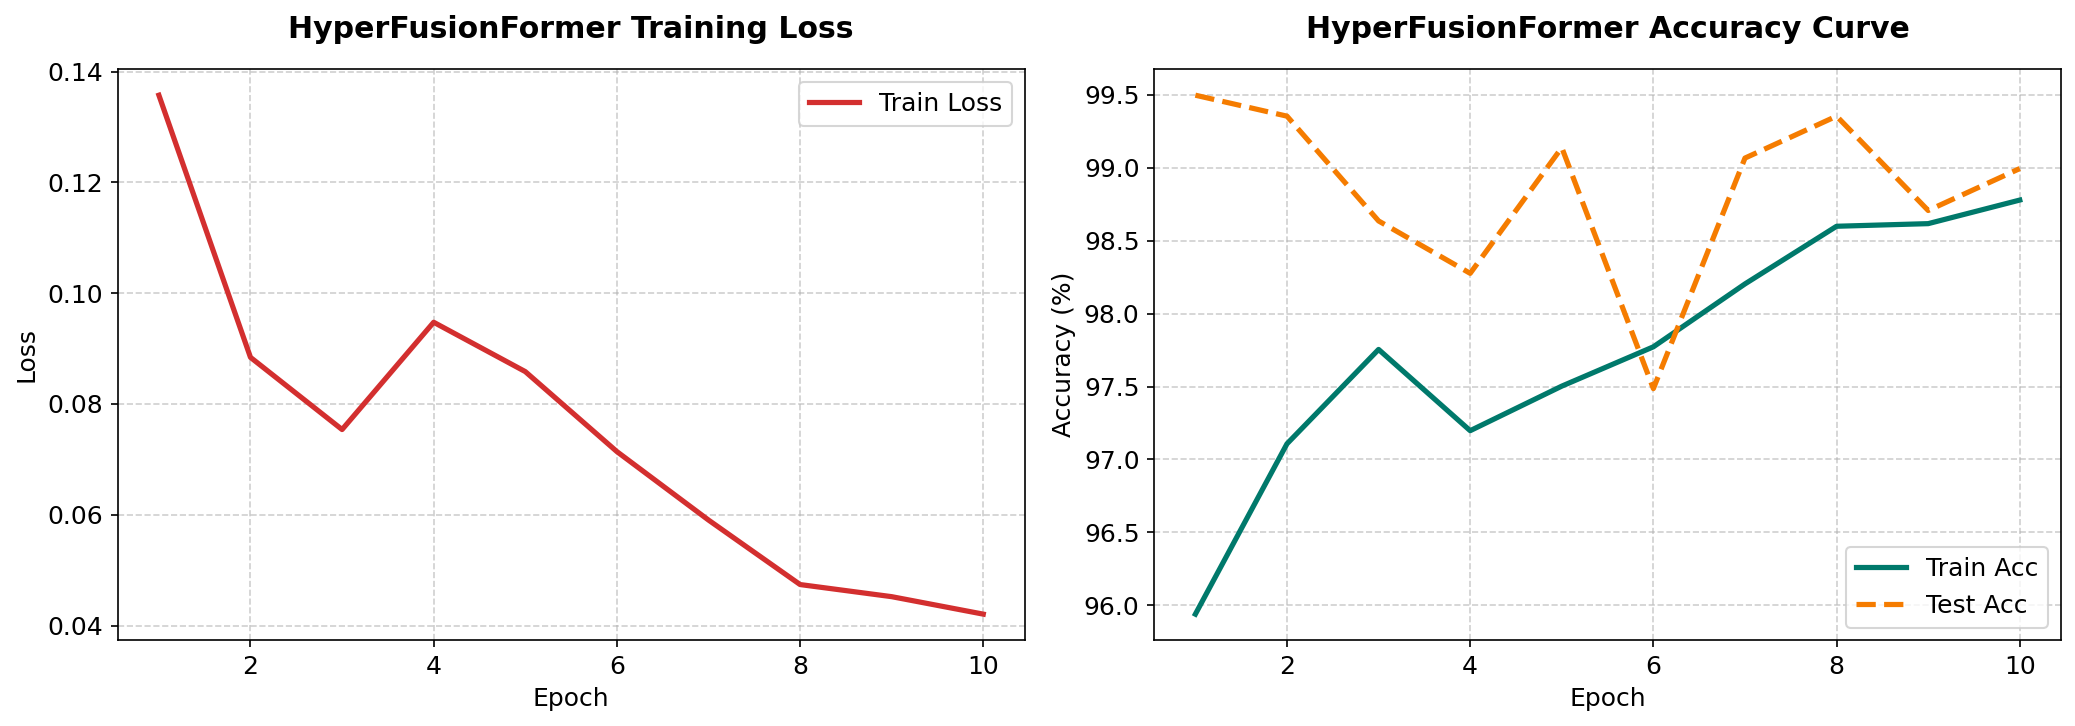

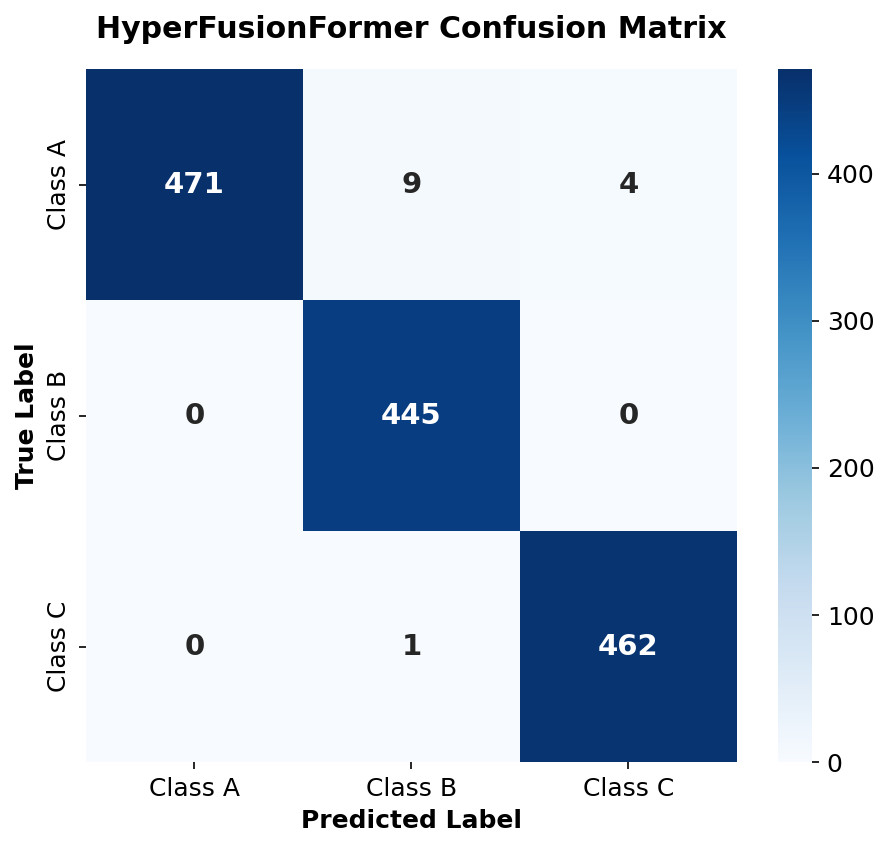

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Plot Curves
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs + 1), history['train_loss'], color='#D32F2F', linewidth=2.5, label='Train Loss')
ax1.set_title('HyperFusionFormer Training Loss', fontweight='bold', pad=15)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.plot(range(1, epochs + 1), history['train_acc'], color='#00796B', linewidth=2.5, label='Train Acc')
ax2.plot(range(1, epochs + 1), history['test_acc'], color='#F57C00', linewidth=2.5, linestyle='--', label='Test Acc')
ax2.set_title('HyperFusionFormer Accuracy Curve', fontweight='bold', pad=15)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

# 2. Confusion Matrix
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        imgs = batch.img.to(device).view(-1, 3, 224, 224)
        outputs = model(imgs, batch.x.to(device), batch.edge_index.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch.y.to(device).cpu().numpy())

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
classes = ['Class A', 'Class B', 'Class C']

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, annot_kws={'size': 14, 'weight': 'bold'})
plt.title('HyperFusionFormer Confusion Matrix', fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import torch

# 1. Gather all predictions and true labels from the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        # Reshape images to standard [Batch, Channels, Height, Width]
        imgs = batch.img.to(device).view(-1, 3, 224, 224)
        graph_x = batch.x.to(device)
        edges = batch.edge_index.to(device)
        labels = batch.y.to(device)

        outputs = model(imgs, graph_x, edges)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Print the comprehensive report
target_names = ['Class A', 'Class B', 'Class C']
report = classification_report(all_labels, all_preds, target_names=target_names)

print("📊 HyperFusionFormer Classification Report:\n")
print(report)

📊 HyperFusionFormer Classification Report:

              precision    recall  f1-score   support

     Class A       1.00      0.97      0.99       484
     Class B       0.98      1.00      0.99       445
     Class C       0.99      1.00      0.99       463

    accuracy                           0.99      1392
   macro avg       0.99      0.99      0.99      1392
weighted avg       0.99      0.99      0.99      1392



In [ ]:
import torch.nn.functional as F

# 1. Define the Inference Function
def predict_sign_language(model, img_tensor, graph_x_tensor, edge_index_tensor, class_names=['A', 'B', 'C']):
    model.eval()
    with torch.no_grad():
        # Ensure batch dimensions exist for a single sample: [1, ...]
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)

        # We don't unsqueeze graph nodes, but we ensure they are on the correct device
        img_tensor = img_tensor.to(device)
        graph_x_tensor = graph_x_tensor.to(device)
        edge_index_tensor = edge_index_tensor.to(device)

        # Forward prediction pass
        logits = model(img_tensor, graph_x_tensor, edge_index_tensor)
        probs = F.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

        return class_names[pred_idx], probs[0][pred_idx].item(), probs[0].cpu().numpy()

print("✅ Inference helper function created successfully!")

# 2. Test the Inference Function on a Single Sample
# Grab the very first sample from the test dataset
sample_data = test_dataset[0]
sample_img = sample_data.img
sample_graph_x = sample_data.x
sample_edges = sample_data.edge_index
true_label_idx = sample_data.y.item()

classes = ['A', 'B', 'C']
predicted_class, confidence, all_probs = predict_sign_language(model, sample_img, sample_graph_x, sample_edges, classes)

print("\n🔮 HyperFusionFormer Inference Test Results:")
print(f"• Ground Truth Label: {classes[true_label_idx]}")
print(f"• Model Prediction:   {predicted_class}")
print(f"• Confidence Score:   {confidence * 100:.2f}%\n")

print("📊 Probability Distribution Across Classes:")
for cls_name, prob in zip(classes, all_probs):
    print(f"  - {cls_name}: {prob * 100:.2f}%")

✅ Inference helper function created successfully!

🔮 HyperFusionFormer Inference Test Results:
• Ground Truth Label: C
• Model Prediction:   C
• Confidence Score:   99.87%

📊 Probability Distribution Across Classes:
  - A: 0.06%
  - B: 0.07%
  - C: 99.87%


In [ ]:
%%writefile HyperFusionFormer/preprocessing/csv_generator.py
import os
import glob
import csv
import math
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

def calc_distance(p1, p2):
    return math.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2 + (p1.z - p2.z)**2)

# Initialize Tasks API with lower confidence for closed/complex hand shapes
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.15,
    min_hand_presence_confidence=0.15
)
detector = vision.HandLandmarker.create_from_options(options)

csv_file_path = 'HyperFusionFormer/dataset/csv/landmarks.csv'

# Headers
headers = ['Image_Name', 'Class']
for i in range(21):
    headers.extend([f'x{i}', f'y{i}', f'z{i}'])
headers.extend(['Dist_Thumb_Index', 'Dist_Index_Middle', 'Dist_Middle_Ring', 'Dist_Ring_Pinky', 'BBox_Xmin', 'BBox_Ymin', 'BBox_Xmax', 'BBox_Ymax', 'Detection_Confidence'])

# Dynamically process all 26 uppercase letters (A-Z)
classes_to_process = [chr(i) for i in range(65, 91)]
total_processed = 0

print("🚀 Starting full 26-class landmark extraction (A-Z)...")

with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)

    for sign_class in classes_to_process:
        image_pattern = f'HyperFusionFormer/dataset/images/**/{sign_class}/*.jpg'
        image_files = glob.glob(image_pattern, recursive=True)

        if not image_files:
            continue

        print(f"Processing Class {sign_class}: Found {len(image_files)} images...")

        for img_path in image_files:
            try:
                mp_image = mp.Image.create_from_file(img_path)
                detection_result = detector.detect(mp_image)

                if detection_result.hand_landmarks:
                    row_data = [os.path.basename(img_path), sign_class]
                    hand = detection_result.hand_landmarks[0]

                    x_vals, y_vals = [], []
                    for landmark in hand:
                        row_data.extend([landmark.x, landmark.y, landmark.z])
                        x_vals.append(landmark.x)
                        y_vals.append(landmark.y)

                    row_data.append(calc_distance(hand[4], hand[8]))
                    row_data.append(calc_distance(hand[8], hand[12]))
                    row_data.append(calc_distance(hand[12], hand[16]))
                    row_data.append(calc_distance(hand[16], hand[20]))
                    row_data.extend([min(x_vals), min(y_vals), max(x_vals), max(y_vals), 0.95])

                    writer.writerow(row_data)
                    total_processed += 1
            except Exception:
                pass

detector.close()
print(f"\n✅ Extraction Complete! Extracted {total_processed} total hand samples across all classes.")

Overwriting HyperFusionFormer/preprocessing/csv_generator.py


📊 Extracting 128D Cross-Attention embeddings for t-SNE plot...


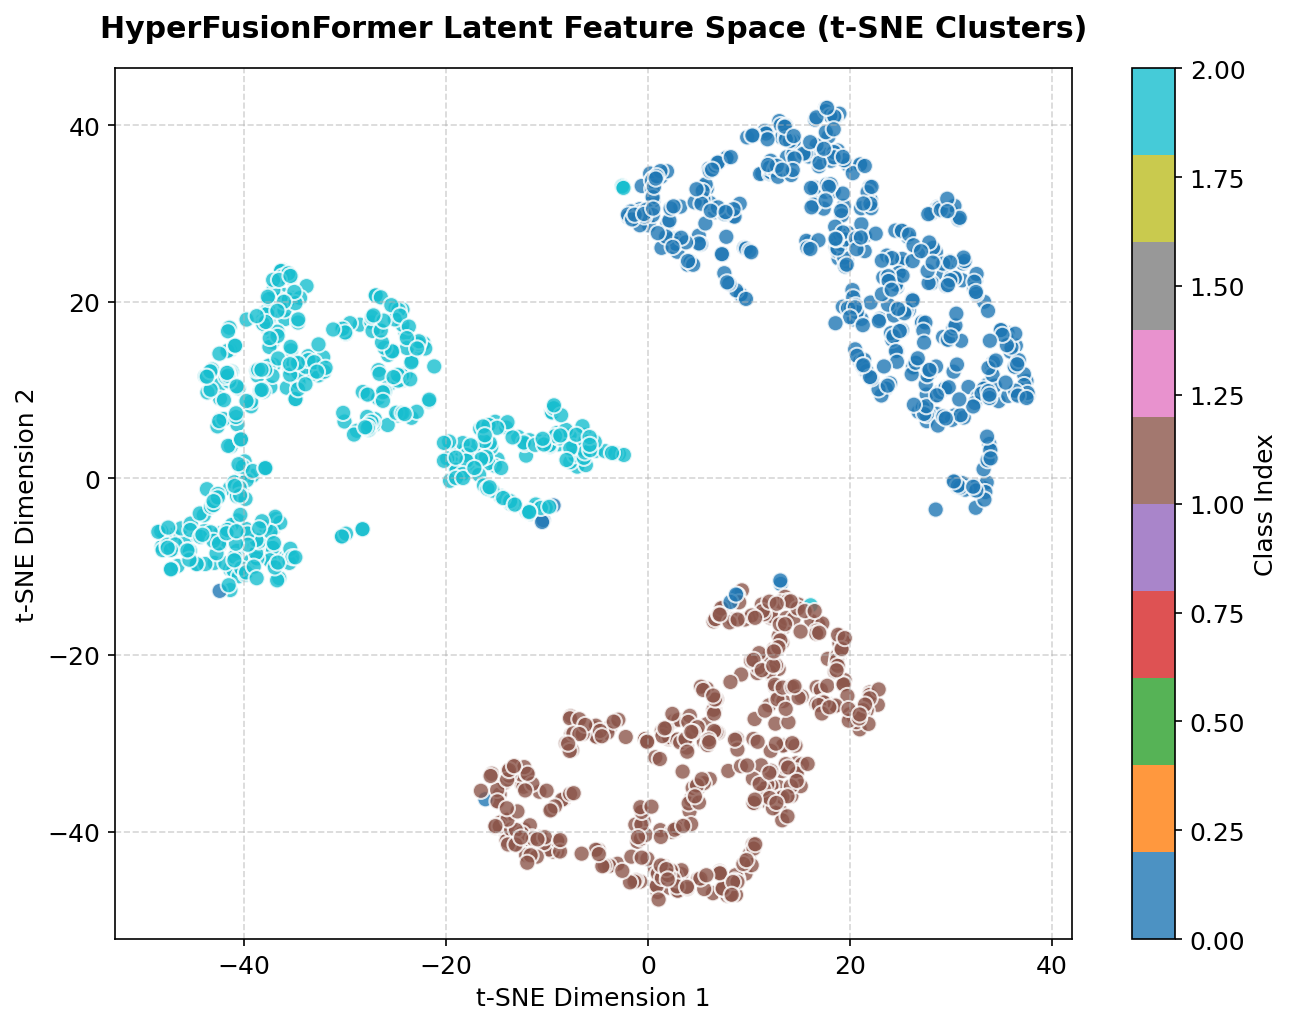

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

print("📊 Extracting 128D Cross-Attention embeddings for t-SNE plot...")

model.eval()
features_list = []
labels_list = []

# Extract features before the final classifier layer
with torch.no_grad():
    for batch in test_loader:
        imgs = batch.img.to(device).view(-1, 3, 224, 224)
        graph_x = batch.x.to(device)
        edges = batch.edge_index.to(device)
        labels = batch.y.to(device)

        # Get intermediate fused representations
        img_feats = model.vision_branch(imgs)
        gcn_feats = model.gcn_branch(graph_x, edges)

        q = img_feats.unsqueeze(1)
        kv = gcn_feats.unsqueeze(1)
        attn_out, _ = model.fusion_module.cross_attn(query=q, key=kv, value=kv)
        fused = model.fusion_module.norm(q + attn_out).squeeze(1)

        features_list.append(fused.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

features_array = np.concatenate(features_list, axis=0)
labels_array = np.concatenate(labels_list, axis=0)

# Compute t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedded_features = tsne.fit_transform(features_array)

# Plot t-SNE Clusters
plt.figure(figsize=(9, 7))
scatter = plt.scatter(embedded_features[:, 0], embedded_features[:, 1], c=labels_array, cmap='tab10', alpha=0.8, edgecolors='w', s=60)
plt.colorbar(scatter, label='Class Index')
plt.title('HyperFusionFormer Latent Feature Space (t-SNE Clusters)', fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
%%writefile HyperFusionFormer/dataset/dataset_loader.py
import torch
import pandas as pd
from torch_geometric.data import Data, Dataset
import cv2
import glob
import os
import torchvision.transforms as transforms
import numpy as np

class MultimodalGraphDataset(Dataset):
    def __init__(self, csv_file, edge_index, is_training=True):
        super().__init__()
        self.data_df = pd.read_csv(csv_file)
        self.edge_index = edge_index
        self.is_training = is_training

        # Dynamically map all 26 letters (A-Z) to integers (0-25)
        self.label_map = {chr(i): i - 65 for i in range(65, 91)}

        # ⚡ OPTIMIZATION: Find all images ONCE and store them in a fast dictionary
        all_imgs = glob.glob('HyperFusionFormer/dataset/images/**/*.jpg', recursive=True)
        self.image_paths = {os.path.basename(p): p for p in all_imgs}

        # Heavy Augmentation for Training to prevent overfitting
        if self.is_training:
            self.image_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomRotation(15),           # Randomly tilt the hand
                transforms.ColorJitter(brightness=0.2),  # Change lighting
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        # Standard normalization for Testing
        else:
            self.image_transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        # 1. Process and Augment the Hand Graph
        node_features = []
        for i in range(21):
            x, y, z = row[f'x{i}'], row[f'y{i}'], row[f'z{i}']
            # Add spatial jitter (noise) during training
            if self.is_training:
                x += np.random.normal(0, 0.005)
                y += np.random.normal(0, 0.005)
                z += np.random.normal(0, 0.005)
            node_features.append([x, y, z])

        x_tensor = torch.tensor(node_features, dtype=torch.float32)

        # 2. Process the Target Label
        sign_class = row['Class']
        y_tensor = torch.tensor([self.label_map[sign_class]], dtype=torch.long)

        # 3. Process the Raw Image (⚡ Instant lookup now!)
        image_name = row['Image_Name']
        img_path = self.image_paths.get(image_name)

        if not img_path:
             img_tensor = torch.zeros((3, 224, 224), dtype=torch.float32)
        else:
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_tensor = self.image_transform(img_rgb)

        # 4. Package Data
        graph_data = Data(x=x_tensor, edge_index=self.edge_index, y=y_tensor)
        graph_data.img = img_tensor
        return graph_data

Overwriting HyperFusionFormer/dataset/dataset_loader.py


In [ ]:
!touch HyperFusionFormer/__init__.py
!touch HyperFusionFormer/dataset/__init__.py
!touch HyperFusionFormer/models/__init__.py
!touch HyperFusionFormer/preprocessing/__init__.py

In [1]:
import sys

# 1. Clear any broken or old versions of the file from Python's memory
for module_name in list(sys.modules.keys()):
    if module_name.startswith('torch_geometric') or module_name.startswith('HyperFusionFormer'):
        del sys.modules[module_name]

# 2. Safely import your newly written class
from HyperFusionFormer.dataset.dataset_loader import MultimodalGraphDataset

print("✅ Memory cleared and new dataset class imported successfully!")

ModuleNotFoundError: No module named 'HyperFusionFormer'

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_max_pool, global_mean_pool

class AttentionGestureNet(torch.nn.Module):
    def __init__(self, num_node_features=3, hidden_channels=64, num_classes=26):
        super().__init__()

        # GATv2 learns which hand joints are most important for each specific sign.
        # 'heads=4' means it looks at the hand from 4 different mathematical perspectives.
        self.gat1 = GATv2Conv(num_node_features, hidden_channels, heads=4, concat=False)
        self.gat2 = GATv2Conv(hidden_channels, hidden_channels, heads=4, concat=False)
        self.gat3 = GATv2Conv(hidden_channels, hidden_channels, heads=4, concat=False)

        # A strong classifier with Dropout to prevent overfitting
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, 128),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.4),
            torch.nn.Linear(128, num_classes)
        )

    def forward(self, x, edge_index, batch):
        # 1. Graph Attention Layers
        x = self.gat1(x, edge_index)
        x = F.elu(x) # ELU handles negative values better than ReLU for coordinates

        x = self.gat2(x, edge_index)
        x = F.elu(x)

        x = self.gat3(x, edge_index)
        x = F.elu(x)

        # 2. Dual Pooling (The Secret Sauce)
        # Max pooling captures the most extreme points (like extended fingers)
        # Mean pooling captures the overall dense shape of the hand (like a fist)
        x_max = global_max_pool(x, batch)
        x_mean = global_mean_pool(x, batch)

        # 3. Combine both perspectives and classify
        x_out = torch.cat([x_max, x_mean], dim=1)
        return self.classifier(x_out)

In [ ]:
!python HyperFusionFormer/preprocessing/csv_generator.py

python3: can't open file '/content/HyperFusionFormer/preprocessing/csv_generator.py': [Errno 2] No such file or directory


In [ ]:
import torch
import pandas as pd
import numpy as np
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
from HyperFusionFormer.models.hypergraph import edge_index  # Added import

class HandGraphDataset(Dataset):
    def __init__(self, csv_file, edge_index, is_training=True):
        super().__init__()
        self.data_df = pd.read_csv(csv_file)
        self.edge_index = edge_index
        self.is_training = is_training
        self.label_map = {chr(i): i - 65 for i in range(65, 91)}

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        # 1. Process just the Hand Graph
        node_features = []
        for i in range(21):
            x, y, z = row[f'x{i}'], row[f'y{i}'], row[f'z{i}']
            # Spatial jitter to prevent overfitting
            if self.is_training:
                x += np.random.normal(0, 0.005)
                y += np.random.normal(0, 0.005)
                z += np.random.normal(0, 0.005)
            node_features.append([x, y, z])

        x_tensor = torch.tensor(node_features, dtype=torch.float32)

        # 2. Process Target Label
        sign_class = row['Class']
        y_tensor = torch.tensor([self.label_map[sign_class]], dtype=torch.long)

        return Data(x=x_tensor, edge_index=self.edge_index, y=y_tensor)


# --- UPDATED INITIALIZATION ---
csv_path = 'HyperFusionFormer/dataset/csv/landmarks.csv'

# Load the full dataset
full_dataset = HandGraphDataset(csv_file=csv_path, edge_index=edge_index, is_training=True)

# Split into 80% train, 20% test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Initialize Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✅ Pure Graph DataLoaders are ready!")

FileNotFoundError: [Errno 2] No such file or directory: 'HyperFusionFormer/dataset/csv/landmarks.csv'